# 08 - Load phase pattern analysis

This notebook extends the training-load work by classifying weeks into loading, holding, unloading, recovery, and high-intensity phases.


## Learning goal

A coach often looks for training phases rather than isolated workouts. With two years of swim workouts and heart-rate summaries, we can infer patterns such as load building, load holding, unloading, recovery, and intensity emphasis.

The main idea is change over time:

$$
\Delta \text{load}_t = \text{load}_t - \text{load}_{t-1}
$$

Code-style implementation:

```python
weekly["load_delta"] = weekly["total_combined_load"].diff()
```

This is an inference from observed data. It does not prove intent, but it gives a structured way to describe training patterns.


## 1) Imports and prepared data

**Expected output:** The cell should run without errors and make the required packages, paths, or helper tools available for the rest of the notebook.


In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd

try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None

warnings.filterwarnings("ignore")

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_DIR = ROOT / "data" / "processed"

weekly_path = PROCESSED_DIR / "weekly_physiology_metrics.csv"
workout_path = PROCESSED_DIR / "workout_physiology_metrics.csv"

if not weekly_path.exists() or not workout_path.exists():
    raise FileNotFoundError("Run 07_training_load_and_physiology.ipynb first.")

weekly = pd.read_csv(weekly_path, parse_dates=["week_start"])
workouts = pd.read_csv(workout_path, parse_dates=["date", "week_start"])

print("Weekly physiology rows:", len(weekly))
print("Workout physiology rows:", len(workouts))
display(weekly.head(3))
display(weekly.tail(3))


Weekly physiology rows: 107
Workout physiology rows: 483


,week_start,sessions,total_distance_km,total_duration_min,mean_avg_hr,max_hr,mean_hrr_intensity,mean_sample_zone_depth,mean_active_zone_depth,total_active_zone_minutes,...,mean_hr_efficiency_proxy,mean_pace_50_s,mean_hr_rise_bpm,mean_hr_rise_bpm_per_min,mean_hr_drop_bpm,mean_hr_drop_bpm_per_min,total_transition_events,load_4w_avg,hr_4w_avg,near_max_4w_avg
0,2024-05-27,2,4.68630,270.786083,141.033889,195.0,0.525063,3.107868,4.105123,181.016667,...,0.494477,70.222801,4.526855,2.263427,-2.101816,-2.802421,196,979.974567,141.033889,26.983195
1,2024-06-03,5,11.97864,446.246724,143.941291,193.0,0.545683,3.454145,4.681709,291.333333,...,0.328437,47.299689,3.910413,1.955206,-4.284491,-5.712655,332,1490.266322,142.487590,59.866520
2,2024-06-10,6,22.82180,847.535848,140.420116,208.0,0.520710,3.174696,4.209618,559.616667,...,0.414918,57.884386,4.120351,2.060175,-3.786241,-5.048321,773,2094.731450,141.798432,79.017949


,week_start,sessions,total_distance_km,total_duration_min,mean_avg_hr,max_hr,mean_hrr_intensity,mean_sample_zone_depth,mean_active_zone_depth,total_active_zone_minutes,...,mean_hr_efficiency_proxy,mean_pace_50_s,mean_hr_rise_bpm,mean_hr_rise_bpm_per_min,mean_hr_drop_bpm,mean_hr_drop_bpm_per_min,total_transition_events,load_4w_avg,hr_4w_avg,near_max_4w_avg
104,2026-06-01,8,23.56590,1129.578412,140.587072,201.0,0.521894,3.165592,4.296387,707.550000,...,0.484728,68.244564,3.522046,1.761023,-4.190165,-5.586887,878,2038.706470,129.907671,62.098885
105,2026-06-08,5,19.08464,902.044291,131.664857,190.0,0.458616,2.734180,4.222080,422.083333,...,0.565231,71.422612,1.022266,0.511133,-3.351796,-4.469061,613,2319.824727,128.500072,68.795728
106,2026-06-15,4,15.88892,561.378514,140.990351,188.0,0.524754,3.195212,4.189885,360.483333,...,0.417267,59.082290,3.295772,1.647886,-2.530858,-3.374477,478,2735.650932,136.758827,84.574892


## 2) Calculate acute and chronic load

Acute load is short-term load. Chronic load is longer-term background load.

$$
\text{acute load}_t = \frac{1}{2}\sum_{i=t-1}^{t}\text{load}_i
$$

Code-style implementation:

```python
weekly["acute_load_2w"] = weekly["total_combined_load"].rolling(2).mean()
```

$$
\text{chronic load}_t = \frac{1}{6}\sum_{i=t-5}^{t}\text{load}_i
$$

Code-style implementation:

```python
weekly["chronic_load_6w"] = weekly["total_combined_load"].rolling(6).mean()
```

The acute-to-chronic ratio estimates whether current load is above or below the recent baseline:

$$
ACR_t = \frac{\text{acute load}_t}{\text{chronic load}_t}
$$

Code-style implementation:

```python
weekly["acute_chronic_ratio"] = weekly["acute_load_2w"] / weekly["chronic_load_6w"]
```

**Expected output:** Expect paired previews: the first 3 rows show the starting structure, and the latest 3 rows help confirm the most recent records look reasonable.


In [2]:
weekly = weekly.sort_values("week_start").reset_index(drop=True)
weekly["load_delta"] = weekly["total_combined_load"].diff()
weekly["load_pct_change"] = weekly["total_combined_load"].pct_change() * 100
weekly["acute_load_2w"] = weekly["total_combined_load"].rolling(2, min_periods=1).mean()
weekly["chronic_load_6w"] = weekly["total_combined_load"].rolling(6, min_periods=2).mean()
weekly["acute_chronic_ratio"] = weekly["acute_load_2w"] / weekly["chronic_load_6w"].replace(0, np.nan)
display(weekly[["week_start", "total_combined_load", "load_delta", "load_pct_change", "acute_chronic_ratio"]].head(3))
display(weekly[["week_start", "total_combined_load", "load_delta", "load_pct_change", "acute_chronic_ratio"]].tail(3))


,week_start,total_combined_load,load_delta,load_pct_change,acute_chronic_ratio
0,2024-05-27,979.974567,NaN,NaN,NaN
1,2024-06-03,2000.558077,1020.583510,104.143877,1.000000
2,2024-06-10,3303.661708,1303.103631,65.137006,1.266086


,week_start,total_combined_load,load_delta,load_pct_change,acute_chronic_ratio
104,2026-06-01,4135.114188,2271.892626,121.933573,1.501974
105,2026-06-08,2749.443246,-1385.670942,-33.509859,1.691247
106,2026-06-15,2194.824731,-554.618516,-20.172030,1.132353


## 3) Identify intensity markers

A week can be high load because it has many minutes, many hard minutes, or both. Near-max HR minutes help flag intensity emphasis.

Near-max intensity share:

$$
\text{near max share} = \frac{\text{near max minutes}}{\text{duration minutes}}
$$

Code-style implementation:

```python
weekly["near_max_share"] = weekly["total_near_max_min"] / weekly["total_duration_min"]
```

High intensity is flagged relative to this athlete's own history:

$$
\text{high intensity week} = \text{near max share} \ge P_{75}(\text{near max share})
$$

Code-style implementation:

```python
weekly["high_intensity_week"] = weekly["near_max_share"] >= weekly["near_max_share"].quantile(.75)
```

**Expected output:** Expect paired previews: the first 3 rows show the starting structure, and the latest 3 rows help confirm the most recent records look reasonable.


In [3]:
weekly["near_max_share"] = weekly["total_near_max_min"] / weekly["total_duration_min"].replace(0, np.nan)
weekly["load_per_hour"] = weekly["total_combined_load"] / (weekly["total_duration_min"].replace(0, np.nan) / 60)
intensity_cutoff = weekly["near_max_share"].quantile(0.75)
load_cutoff = weekly["total_combined_load"].quantile(0.75)
low_load_cutoff = weekly["total_combined_load"].quantile(0.25)
weekly["high_intensity_week"] = weekly["near_max_share"] >= intensity_cutoff
weekly["high_load_week"] = weekly["total_combined_load"] >= load_cutoff
weekly["low_load_week"] = weekly["total_combined_load"] <= low_load_cutoff
display(weekly[["week_start", "near_max_share", "load_per_hour", "high_intensity_week", "high_load_week", "low_load_week"]].head(3))
display(weekly[["week_start", "near_max_share", "load_per_hour", "high_intensity_week", "high_load_week", "low_load_week"]].tail(3))


,week_start,near_max_share,load_per_hour,high_intensity_week,high_load_week,low_load_week
0,2024-05-27,0.099648,217.139941,False,False,True
1,2024-06-03,0.207844,268.984573,False,False,False
2,2024-06-10,0.138426,233.877662,False,True,False


,week_start,near_max_share,load_per_hour,high_intensity_week,high_load_week,low_load_week
104,2026-06-01,0.098916,219.645532,False,True,False
105,2026-06-08,0.089814,182.880815,False,False,False
106,2026-06-15,0.143219,234.582337,False,False,False


## 4) Classify load phases

A simple rule-based classifier can identify training phases.

Loading:

$$
\Delta\text{load} > 0 \quad \text{and} \quad ACR \ge 1.05
$$

Holding:

$$
|\Delta\text{load percent}| < 10\% \quad \text{and} \quad 0.90 \le ACR \le 1.10
$$

Unloading:

$$
\Delta\text{load} < 0 \quad \text{and} \quad ACR < 0.95
$$

Recovery:

$$
\text{load} \le P_{25}(\text{load history})
$$

Code-style implementation:

```python
np.select([loading_condition, holding_condition, unloading_condition, recovery_condition], labels)
```

**Expected output:** Expect a small row preview. Use it to inspect column names, units, ordering, and whether the values look plausible.


In [4]:
loading = (weekly["load_delta"] > 0) & (weekly["acute_chronic_ratio"] >= 1.05)
holding = weekly["load_pct_change"].abs().lt(10) & weekly["acute_chronic_ratio"].between(0.90, 1.10)
unloading = (weekly["load_delta"] < 0) & (weekly["acute_chronic_ratio"] < 0.95)
recovery = weekly["low_load_week"]

weekly["load_phase"] = np.select(
    [recovery, loading, unloading, holding],
    ["recovery", "loading", "unloading", "holding"],
    default="mixed"
)
weekly["phase_with_intensity"] = np.where(
    weekly["high_intensity_week"],
    weekly["load_phase"] + " + intensity",
    weekly["load_phase"]
)
weekly[["week_start", "total_combined_load", "acute_chronic_ratio", "load_phase", "high_intensity_week", "phase_with_intensity"]].tail(20)


,week_start,total_combined_load,acute_chronic_ratio,load_phase,high_intensity_week,phase_with_intensity
87,2026-02-02,2748.951797,1.074480,mixed,True,mixed + intensity
88,2026-02-09,4603.408063,1.240157,loading,True,loading + intensity
89,2026-02-16,3263.073557,1.370567,mixed,False,mixed
90,2026-02-23,729.128993,0.709999,recovery,False,recovery
91,2026-03-02,3213.014453,0.660372,mixed,False,mixed
92,2026-03-09,2950.061444,1.056066,holding,False,holding
93,2026-03-16,1830.684454,0.864544,unloading,False,unloading
94,2026-03-23,2840.628527,0.945190,mixed,False,mixed
95,2026-03-30,1777.663800,1.038504,mixed,False,mixed
96,2026-04-06,2036.650610,0.781157,mixed,False,mixed


## 5) Summarize phase patterns

Phase summaries show how training was distributed across the two-year history.

Average load by phase:

$$
\bar{x}_{phase} = \frac{1}{n_{phase}}\sum \text{load}_{week}
$$

Code-style implementation:

```python
phase_summary = weekly.groupby("load_phase").agg(avg_load=("total_combined_load", "mean"))
```

This helps answer questions like: Were loading weeks actually higher volume or just higher HR intensity?

**Expected output:** Expect grouped summaries rather than individual records. Compare groups to find patterns by week, event, stroke, phase, or other categories.


In [5]:
phase_summary = (
    weekly.groupby("load_phase", as_index=False)
    .agg(
        weeks=("week_start", "count"),
        avg_load=("total_combined_load", "mean"),
        avg_distance_km=("total_distance_km", "mean"),
        avg_duration_min=("total_duration_min", "mean"),
        avg_hr=("mean_avg_hr", "mean"),
        avg_near_max_share=("near_max_share", "mean"),
        avg_acr=("acute_chronic_ratio", "mean"),
    )
    .sort_values("avg_load", ascending=False)
)
phase_summary


,load_phase,weeks,avg_load,avg_distance_km,avg_duration_min,avg_hr,avg_near_max_share,avg_acr
1,loading,22,3328.761707,19.614509,748.887421,142.959790,0.224830,1.339133
0,holding,5,2943.726989,14.714792,593.066544,139.758961,0.383596,1.019169
2,mixed,42,2609.633047,15.605990,587.439926,140.631955,0.257148,1.039518
4,unloading,11,2001.749145,12.710588,459.895151,141.813108,0.228119,0.848564
3,recovery,27,1080.383329,7.422961,319.529624,133.691872,0.121772,0.754187


## 6) Phase transitions

Transitions help describe the training rhythm: for example, loading to holding, loading to unloading, or recovery to loading.

A transition is the previous phase followed by the current phase:

$$
\text{transition}_t = \text{phase}_{t-1} \rightarrow \text{phase}_t
$$

Code-style implementation:

```python
weekly["phase_transition"] = weekly["load_phase"].shift(1) + " -> " + weekly["load_phase"]
```

**Expected output:** Expect paired previews: the first 3 rows show the starting structure, and the latest 3 rows help confirm the most recent records look reasonable.


In [6]:
weekly["previous_phase"] = weekly["load_phase"].shift(1)
weekly["phase_transition"] = weekly["previous_phase"].fillna("start") + " -> " + weekly["load_phase"]
transition_summary = weekly["phase_transition"].value_counts().rename_axis("transition").reset_index(name="weeks")
display(transition_summary.head(3))
display(transition_summary.tail(3))


,transition,weeks
0,loading -> mixed,13
1,recovery -> mixed,12
2,recovery -> recovery,11


,transition,weeks
17,holding -> holding,1
18,holding -> mixed,1
19,holding -> recovery,1


## 7) Visual timeline

The timeline gives a coach-like view of phase blocks over time. If plotting is unavailable, the saved tables still contain the phase labels.

**Expected output:** Expect grouped summaries rather than individual records. Compare groups to find patterns by week, event, stroke, phase, or other categories.


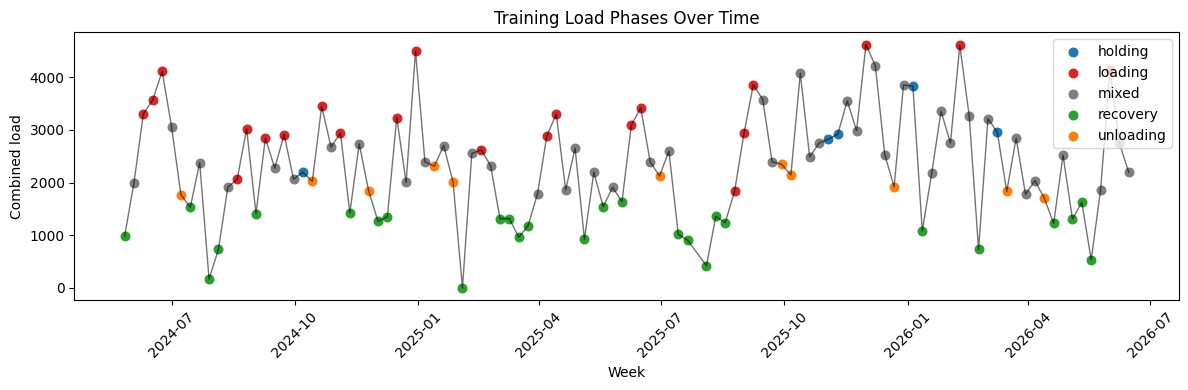

In [7]:
if plt is None:
    print("matplotlib is not installed, so the visual timeline is skipped.")
else:
    colors = {
        "loading": "tab:red",
        "holding": "tab:blue",
        "unloading": "tab:orange",
        "recovery": "tab:green",
        "mixed": "tab:gray",
    }
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(weekly["week_start"], weekly["total_combined_load"], color="black", linewidth=1, alpha=0.55)
    for phase, group in weekly.groupby("load_phase"):
        ax.scatter(group["week_start"], group["total_combined_load"], label=phase, color=colors.get(phase, "tab:gray"), s=38)
    ax.set_title("Training Load Phases Over Time")
    ax.set_xlabel("Week")
    ax.set_ylabel("Combined load")
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


## 8) Save phase pattern outputs

These outputs can feed the web app or later student analysis.

Data flow:

$$
\text{weekly physiology} \rightarrow \text{phase labels} \rightarrow \text{phase summaries}
$$

Code-style implementation:

```python
weekly.to_csv(PROCESSED_DIR / "weekly_load_phase_patterns.csv", index=False)
```

**Expected output:** Expect processed files or folders to be written for later notebooks and web-app views. The key interpretation is that downstream data is now prepared.


In [ ]:
weekly.to_csv(PROCESSED_DIR / "weekly_load_phase_patterns.csv", index=False)
phase_summary.to_csv(PROCESSED_DIR / "load_phase_summary.csv", index=False)
transition_summary.to_csv(PROCESSED_DIR / "load_phase_transitions.csv", index=False)

print("Saved load phase outputs:")
print(PROCESSED_DIR / "weekly_load_phase_patterns.csv")
print(PROCESSED_DIR / "load_phase_summary.csv")
print(PROCESSED_DIR / "load_phase_transitions.csv")


## Periodization wave score

Training appears periodized when load rises and falls in repeated waves instead of staying flat. This project-level score is a learning metric that combines 4-week load amplitude, unload frequency, loading/unloading alternation, load variability, and a missing-data penalty.

Expected output: a one-row summary table with a 0-100 periodization score and the components used to calculate it. A higher score means the prepared weekly data shows more visible loading and unloading waves.

Math definition:

$$Score = 28A_{4w} + 22U + 26T + 24CV_{load} - 18M$$

Where $A_{4w}$ is rolling 4-week load amplitude, $U$ is unload frequency, $T$ is loading/unloading alternation, $CV_{load}$ is load variability, and $M$ is the missing-data penalty.

Code-style implementation:

```python
score = 28 * rolling_4w_load_amplitude + 22 * unload_frequency + 26 * loading_unloading_alternation + 24 * load_variability - 18 * missing_data_penalty
```

In [9]:
from pathlib import Path
import math
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
processed_dir = PROJECT_ROOT / "data" / "processed"
public_data_dir = PROJECT_ROOT / "app" / "public" / "data"

weekly = pd.read_csv(processed_dir / "weekly_physiology_metrics.csv").sort_values("week_start")
phases = pd.read_csv(processed_dir / "weekly_load_phase_patterns.csv").sort_values("week_start")
loads = weekly["total_combined_load"].fillna(0).astype(float).to_list()
nonzero_loads = [value for value in loads if value > 0]

rolling_amplitudes = []
for index in range(max(0, len(loads) - 3)):
    window = loads[index:index + 4]
    avg_load = sum(window) / len(window)
    if avg_load > 0:
        rolling_amplitudes.append((max(window) - min(window)) / avg_load)
rolling_4w_load_amplitude = sum(rolling_amplitudes) / len(rolling_amplitudes) if rolling_amplitudes else 0

def phase_group(value):
    text = str(value).lower()
    if any(token in text for token in ["unload", "recovery", "deload", "low"]):
        return "unload"
    if any(token in text for token in ["load", "build", "peak", "high"]):
        return "load"
    if any(token in text for token in ["hold", "maintain", "stable"]):
        return "hold"
    return "mixed"

phase_column = "load_phase" if "load_phase" in phases.columns else "phase"
phase_groups = phases[phase_column].map(phase_group).to_list()
unload_frequency = phase_groups.count("unload") / len(phase_groups) if phase_groups else 0
alternation_pairs = {"load:unload", "unload:load", "load:mixed", "mixed:unload"}
alternations = sum(1 for previous, current in zip(phase_groups, phase_groups[1:]) if f"{previous}:{current}" in alternation_pairs)
loading_unloading_alternation = alternations / max(1, len(phase_groups) - 1)
load_mean = sum(nonzero_loads) / len(nonzero_loads) if nonzero_loads else 0
load_variability = (pd.Series(nonzero_loads).std(ddof=0) / load_mean) if load_mean else 0
missing_data_penalty = loads.count(0) / len(loads) if loads else 0

score = max(0, min(100,
    28 * rolling_4w_load_amplitude
    + 22 * unload_frequency
    + 26 * loading_unloading_alternation
    + 24 * load_variability
    - 18 * missing_data_penalty
))
label = "Strong waves" if score >= 70 else "Moderate waves" if score >= 45 else "Light waves" if score >= 25 else "Mostly steady"

periodization_summary = pd.DataFrame([{
    "metric": "periodization_score",
    "value": round(score, 3),
    "label": label,
    "rolling_4w_load_amplitude": round(rolling_4w_load_amplitude, 6),
    "unload_frequency": round(unload_frequency, 6),
    "loading_unloading_alternation": round(loading_unloading_alternation, 6),
    "load_variability": round(load_variability, 6),
    "missing_data_penalty": round(missing_data_penalty, 6),
    "weeks_used": len(weekly),
    "phase_rows_used": len(phases),
    "formula": "28*rolling_4w_load_amplitude + 22*unload_frequency + 26*loading_unloading_alternation + 24*load_variability - 18*missing_data_penalty, clipped 0-100",
    "interpretation": "Higher values indicate more visible training waves from repeated load changes, unload weeks, and loading/unloading alternation.",
}])

periodization_summary.to_csv(processed_dir / "periodization_summary.csv", index=False)
periodization_summary.to_csv(public_data_dir / "periodization_summary.csv", index=False)

display(periodization_summary.head(3))
display(periodization_summary.tail(3))

,metric,value,label,rolling_4w_load_amplitude,unload_frequency,loading_unloading_alternation,load_variability,missing_data_penalty,weeks_used,phase_rows_used,formula,interpretation
0,periodization_score,49.486,Moderate waves,0.826203,0.35514,0.339623,0.411573,0.009346,107,107,28*rolling_4w_load_amplitude + 22*unload_frequ...,Higher values indicate more visible training w...


,metric,value,label,rolling_4w_load_amplitude,unload_frequency,loading_unloading_alternation,load_variability,missing_data_penalty,weeks_used,phase_rows_used,formula,interpretation
0,periodization_score,49.486,Moderate waves,0.826203,0.35514,0.339623,0.411573,0.009346,107,107,28*rolling_4w_load_amplitude + 22*unload_frequ...,Higher values indicate more visible training w...
